<a href="https://colab.research.google.com/github/kokchun/Databehandling-AI22/blob/main/Lectures/L4.1-api-stocks.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; for interacting with the code


---
# Lecture notes - Stockdata 1 - API
---

This is a lecture note on stock data from API - but it's built upon contents from pandas and previous course:

- Python programming

<p class = "alert alert-info" role="alert"><b>Note</b> that this lecture note gives a brief introduction to merging. I encourage you to read further about API.

Read more

- [video - API-key .env](https://www.youtube.com/watch?v=YdgIWTYQ69A)
- [wikipedia - REST API theory](https://en.wikipedia.org/wiki/Representational_state_transfer)
- [video - Python - requests](https://www.youtube.com/watch?v=tb8gHvYlCFs)
- [w3schools - requests](https://www.w3schools.com/python/module_requests.asp)

---


## Stocks API

Go into [Alpha Vantage](https://www.alphavantage.co/documentation/) and read the documentation of the time series APIs

- Go into [claim API key](https://www.alphavantage.co/support/#api-key) and fill in the form to claim your free API-key

- You will be using the API key to access stock data

- Create a file called .env and type:

```py
ALPHA_API_KEY = ...
```

- the dots should be your API key
- go into your .gitignore file in your repo and make sure that there is .env there so that you don't push the .env file to a public Github repo where anyone can access your key and do stuffs in your name

**Setup**

- pipenv install python-dotenv

[Symbols of stocks](https://www.nasdaq.com/market-activity/stocks/screener) that is useful for get-request


In [11]:
import os
from dotenv import load_dotenv
import requests
import pandas as pd

load_dotenv()
api_key = os.getenv("ALPHA_API_KEY")
# NOTE: you can print it for your own validation, but remove the print before pushing to Github

symbols = ["AAPL", "NVDA", "TSLA", "IBM"]
stock_list = []

for symbol in symbols:
    function = "TIME_SERIES_INTRADAY"

    url = f'https://www.alphavantage.co/query?function={function}&symbol={symbol}&interval=5min&apikey={api_key}'
    #url = f'https://www.alphavantage.co/query?function={function}&symbol={symbol}&apikey={api_key}'
    data = requests.get(url).json()
    df = pd.DataFrame(data["Time Series (5min)"]).transpose()
    df = df["4. close"].rename(symbol).astype(float)
    stock_list.append(df)


In [12]:
stock_list

[2025-10-31 19:55:00    269.9995
 2025-10-31 19:50:00    269.9700
 2025-10-31 19:45:00    269.9500
 2025-10-31 19:40:00    269.9975
 2025-10-31 19:35:00    269.9500
                          ...   
 2025-10-31 12:00:00    271.1448
 2025-10-31 11:55:00    271.4500
 2025-10-31 11:50:00    271.0400
 2025-10-31 11:45:00    270.6850
 2025-10-31 11:40:00    271.0200
 Name: AAPL, Length: 100, dtype: float64,
 2025-10-31 19:55:00    202.6200
 2025-10-31 19:50:00    202.7800
 2025-10-31 19:45:00    202.7400
 2025-10-31 19:40:00    202.7797
 2025-10-31 19:35:00    202.7650
                          ...   
 2025-10-31 12:00:00    204.0299
 2025-10-31 11:55:00    203.7750
 2025-10-31 11:50:00    204.3635
 2025-10-31 11:45:00    204.4150
 2025-10-31 11:40:00    205.2900
 Name: NVDA, Length: 100, dtype: float64,
 2025-10-31 19:55:00    456.0600
 2025-10-31 19:50:00    455.9500
 2025-10-31 19:45:00    455.6200
 2025-10-31 19:40:00    455.6185
 2025-10-31 19:35:00    455.5600
                         

In [13]:
# concatenate the list of series to a df
stocks = pd.concat(stock_list, axis=1)
stocks


,AAPL,NVDA,TSLA,IBM
2025-10-31 19:55:00,269.9995,202.6200,456.0600,307.310
2025-10-31 19:50:00,269.9700,202.7800,455.9500,307.800
2025-10-31 19:45:00,269.9500,202.7400,455.6200,307.250
2025-10-31 19:40:00,269.9975,202.7797,455.6185,307.870
2025-10-31 19:35:00,269.9500,202.7650,455.5600,307.600
...,...,...,...,...
2025-10-31 12:00:00,271.1448,204.0299,452.8000,304.455
2025-10-31 11:55:00,271.4500,203.7750,453.7800,304.290
2025-10-31 11:50:00,271.0400,204.3635,454.4250,304.325
2025-10-31 11:45:00,270.6850,204.4150,454.9300,304.470


In [14]:
import plotly_express as px

# initial plot
px.line(stocks, x=stocks.index, y=[
        "AAPL", "NVDA", "TSLA", "IBM"],
        labels={"variable": "Stock", "index": "Year", "value": "Value $"},
        title="Some stocks", log_y=True)


---
## Working with time series


In [15]:
print(stocks.index.dtype)
# type cast index from object to datetime
stocks.index = pd.to_datetime(stocks.index)
print(stocks.index.dtype)
stocks.head()


object
datetime64[ns]


,AAPL,NVDA,TSLA,IBM
2025-10-31 19:55:00,269.9995,202.6200,456.0600,307.31
2025-10-31 19:50:00,269.9700,202.7800,455.9500,307.80
2025-10-31 19:45:00,269.9500,202.7400,455.6200,307.25
2025-10-31 19:40:00,269.9975,202.7797,455.6185,307.87
2025-10-31 19:35:00,269.9500,202.7650,455.5600,307.60


In [16]:
stocks.loc["2025-10-31 19:55:00"]  # gives all data where year is 2020


AAPL    269.9995
NVDA    202.6200
TSLA    456.0600
IBM     307.3100
Name: 2025-10-31 19:55:00, dtype: float64

In [19]:
stocks.sort_index().loc["2024-11-03":"2025-12-04"]  # gives all rows between these times


,AAPL,NVDA,TSLA,IBM
2025-10-31 11:40:00,271.0200,205.2900,455.6209,305.344
2025-10-31 11:45:00,270.6850,204.4150,454.9300,304.470
2025-10-31 11:50:00,271.0400,204.3635,454.4250,304.325
2025-10-31 11:55:00,271.4500,203.7750,453.7800,304.290
2025-10-31 12:00:00,271.1448,204.0299,452.8000,304.455
...,...,...,...,...
2025-10-31 19:35:00,269.9500,202.7650,455.5600,307.600
2025-10-31 19:40:00,269.9975,202.7797,455.6185,307.870
2025-10-31 19:45:00,269.9500,202.7400,455.6200,307.250
2025-10-31 19:50:00,269.9700,202.7800,455.9500,307.800


---
## Plot 4 stocks in subplots


array([[<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)
array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)


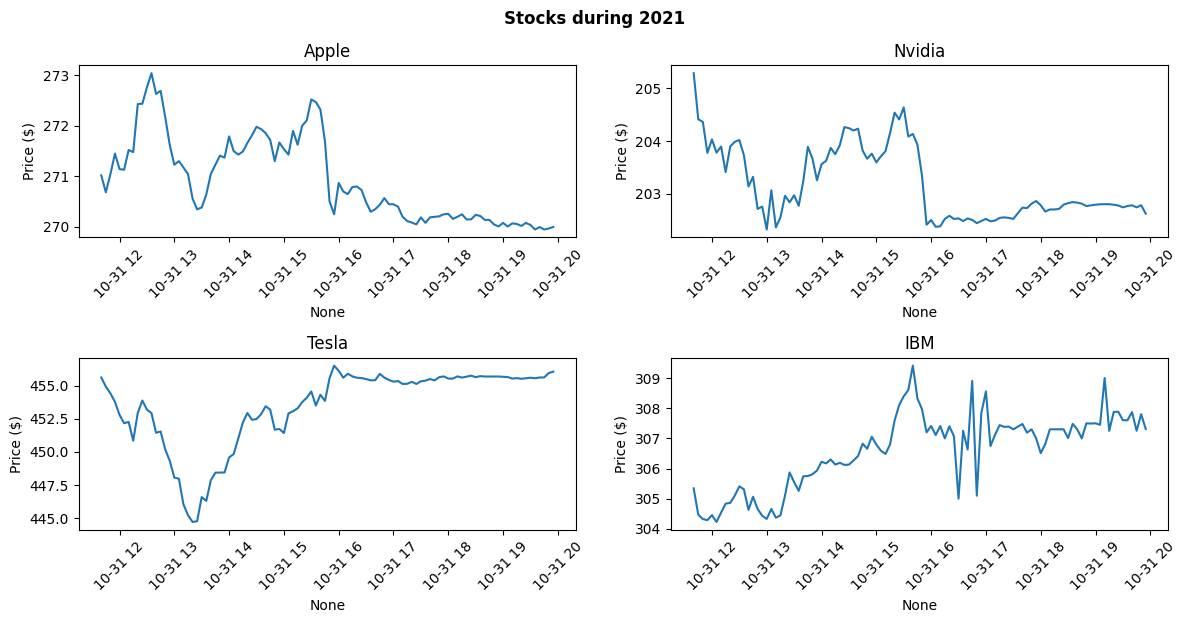

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, dpi=100, figsize=(12,6))

# 2D array -> 2D array has a method flatten() to create a numpy flattened array
print(repr(axes))
print(repr(axes.flatten()))

stock_names = {"AAPL": "Apple", "NVDA": "Nvidia",
               "TSLA": "Tesla", "IBM": "IBM"}

stocks_2022 = stocks.loc["2025"]

for ax, symbol in zip(axes.flatten(), stock_names):
    sns.lineplot(data=stocks_2022, x=stocks_2022.index, y=symbol, ax=ax)
    ax.tick_params(axis="x", rotation=45)
    ax.set(title=f"{stock_names[symbol]}", ylabel="Price ($)")
    #ax.grid()

fig.tight_layout()
fig.suptitle("Stocks during 2021", y=1.03, fontweight="bold");

---
## Download csv

In [ ]:
import time

symbols = ["AAPL", "NVDA", "TSLA", "IBM"]
stock_list = []

for symbol in symbols:
    for function, time_column in zip(["TIME_SERIES_DAILY", "TIME_SERIES_INTRADAY_EXTENDED"], ["timestamp", "time"]):
        url = f"https://www.alphavantage.co/query?function={function}&symbol={symbol}&apikey={api_key}&datatype=csv&outputsize=full&interval=60min"

        df = pd.read_csv(url)
        df.set_index(df[time_column], inplace=True)
        df.index = pd.to_datetime(df.index)
        df.drop(time_column, axis=1, inplace=True)
        df.to_csv(f"../Data/Stocksdata/{symbol}_{function}.csv")

        # to not overload API
        time.sleep(15)

---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---
